# Exploración del dataset IEEE-CIS Fraud Detection

Primer vistazo al dataset `ieee-fraud-detection` (Kaggle), para evaluar si sirve para el simulador
temporal que se venía discutiendo para Physionet. A diferencia de Physionet y Diabetes, **este dataset
no está registrado en TableShift** — se carga directo desde los CSV crudos en
`data/raw/ieee-fraud-detection/`.

**Por qué es prometedor:** cada fila tiene `TransactionDT`, un reloj real en segundos (no una fecha de
calendario, pero sí continuo y exacto) que cubre 182 días seguidos en train. Train y test ya vienen
separados **cronológicamente** por Kaggle (test empieza justo donde termina train) — es uno de los
ejemplos más conocidos de dataset tabular con drift temporal *real*, no inyectado.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darl.utils import find_project_root

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_DIR = find_project_root() / "data" / "raw" / "ieee-fraud-detection"

df_train = pd.read_csv(DATA_DIR / "train_transaction.csv")
print(f"Shape: {df_train.shape}")
print(f"Prevalencia isFraud: {df_train['isFraud'].mean():.4f}")

Shape: (590540, 394)
Prevalencia isFraud: 0.0350


## 1. El reloj temporal — `TransactionDT`

Segundos desde un punto de referencia arbitrario. Lo convertimos a "día de la simulación" (día 0, 1,
2... 181) para poder ver cómo evoluciona el fraude a lo largo del tiempo.

In [2]:
df_train["day"] = (df_train["TransactionDT"] // 86400).astype(int)
df_train["hour_of_day"] = (df_train["TransactionDT"] % 86400) // 3600

print(f"Rango: día {df_train['day'].min()} a día {df_train['day'].max()} ({df_train['day'].nunique()} días)")
print(f"Transacciones por día (promedio): {len(df_train) / df_train['day'].nunique():.0f}")

Rango: día 1 a día 182 (182 días)
Transacciones por día (promedio): 3245


## 2. La gráfica clave — tasa de fraude por día

Esto es lo que buscamos: ¿el fraude cambia de comportamiento con el tiempo, de forma natural, sin que
nosotros inyectemos nada?

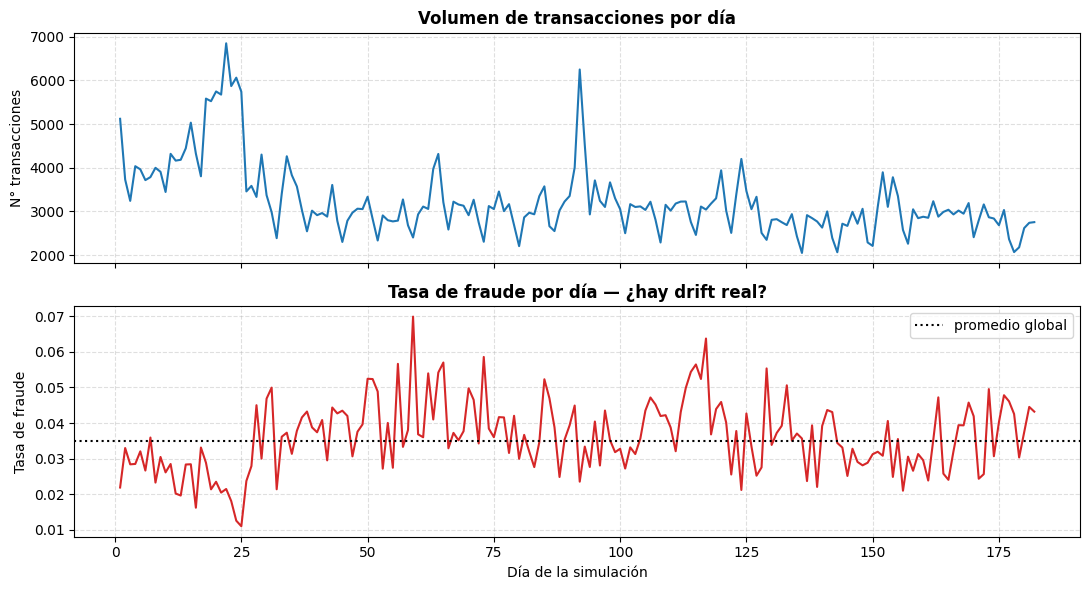

In [3]:
daily = df_train.groupby("day").agg(
    n_transactions=("isFraud", "size"),
    fraud_rate=("isFraud", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(daily["day"], daily["n_transactions"], color="#1f77b4")
axes[0].set_ylabel("N° transacciones")
axes[0].set_title("Volumen de transacciones por día", fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.4)

axes[1].plot(daily["day"], daily["fraud_rate"], color="#d62728")
axes[1].axhline(df_train["isFraud"].mean(), color="black", linestyle=":", label="promedio global")
axes[1].set_ylabel("Tasa de fraude")
axes[1].set_xlabel("Día de la simulación")
axes[1].set_title("Tasa de fraude por día — ¿hay drift real?", fontweight="bold")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Monto de la transacción (`TransactionAmt`)

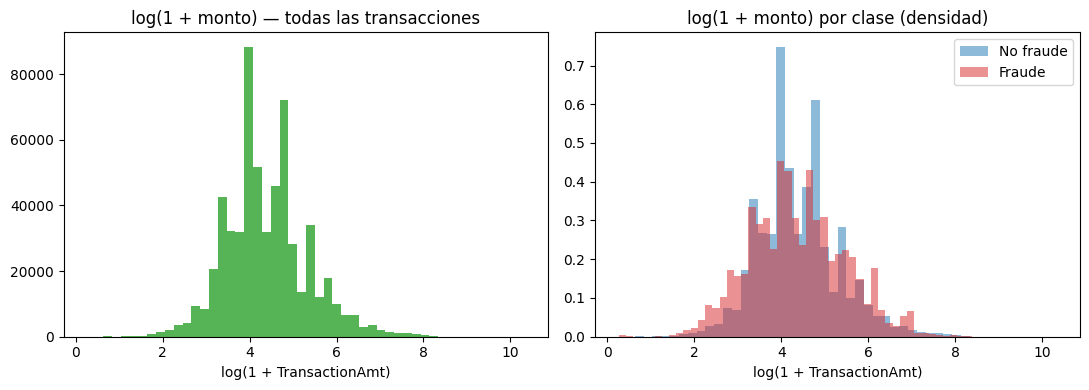

            count        mean         std    min     25%   50%    75%        max
isFraud                                                                         
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0  31937.391
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   5191.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(np.log1p(df_train["TransactionAmt"]), bins=50, color="#2ca02c", alpha=0.8)
axes[0].set_title("log(1 + monto) — todas las transacciones")
axes[0].set_xlabel("log(1 + TransactionAmt)")

axes[1].hist(np.log1p(df_train.loc[df_train.isFraud == 0, "TransactionAmt"]), bins=50, alpha=0.5, label="No fraude", color="#1f77b4", density=True)
axes[1].hist(np.log1p(df_train.loc[df_train.isFraud == 1, "TransactionAmt"]), bins=50, alpha=0.5, label="Fraude", color="#d62728", density=True)
axes[1].set_title("log(1 + monto) por clase (densidad)")
axes[1].set_xlabel("log(1 + TransactionAmt)")
axes[1].legend()
plt.tight_layout()
plt.show()

print(df_train.groupby("isFraud")["TransactionAmt"].describe())

## 4. Panorama de columnas — cuánto falta

Con 394 columnas (339 son las anónimas `V1`...`V339` de Vesta), lo primero es ver qué tan completas
están.

In [5]:
missing = df_train.isna().mean().sort_values(ascending=False)
print("Top 15 columnas con más datos faltantes:")
print(missing.head(15))
print()
print(f"Columnas con más del 50% de datos faltantes: {(missing > 0.5).sum()} de {len(missing)}")
print(f"Columnas sin ningún dato faltante: {(missing == 0).sum()} de {len(missing)}")

Top 15 columnas con más datos faltantes:
dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V149     0.861237
V141     0.861237
V146     0.861237
V154     0.861237
V162     0.861237
V142     0.861237
dtype: float64

Columnas con más del 50% de datos faltantes: 174 de 396
Columnas sin ningún dato faltante: 22 de 396


## 5. Variables categóricas principales

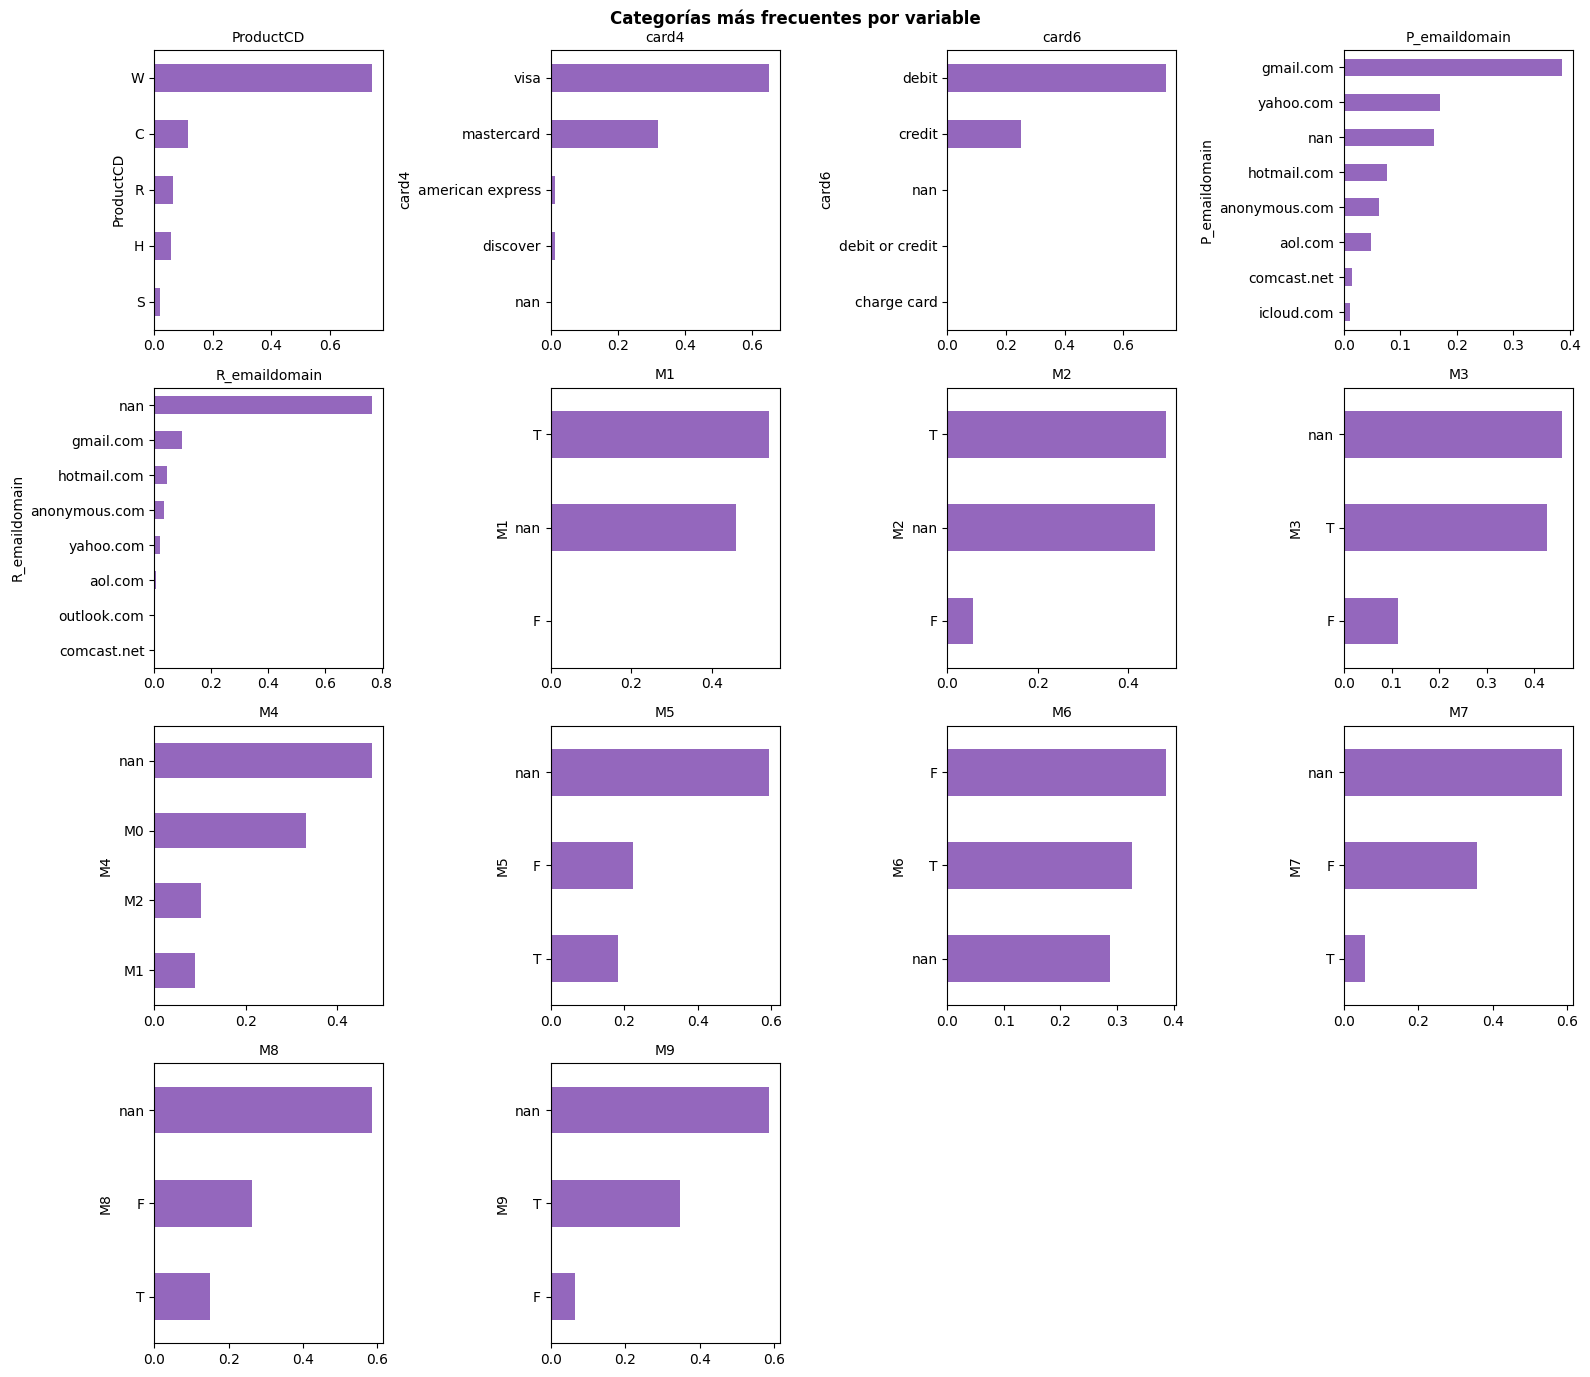

In [6]:
CAT_COLS = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"] + [f"M{i}" for i in range(1, 10)]
CAT_COLS = [c for c in CAT_COLS if c in df_train.columns]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.flatten(), CAT_COLS):
    counts = df_train[col].astype(str).value_counts(normalize=True).head(8)
    counts.sort_values().plot.barh(ax=ax, color="#9467bd")
    ax.set_title(col, fontsize=10)
for ax in axes.flatten()[len(CAT_COLS):]:
    ax.axis("off")
plt.suptitle("Categorías más frecuentes por variable", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Tasa de fraude por variable categórica

¿Alguna de estas variables separa bien fraude de no-fraude?

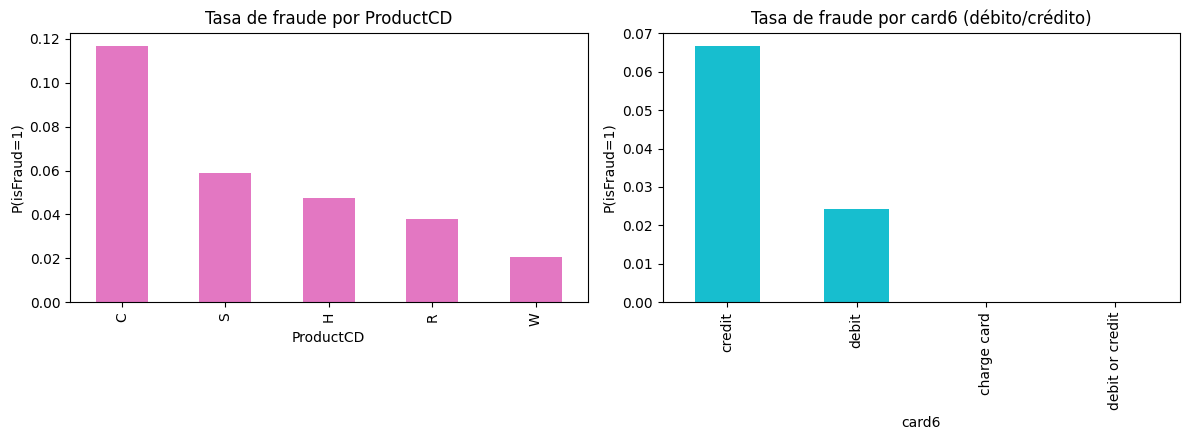

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df_train.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False).plot.bar(ax=axes[0], color="#e377c2")
axes[0].set_title("Tasa de fraude por ProductCD")
axes[0].set_ylabel("P(isFraud=1)")

df_train.groupby("card6")["isFraud"].mean().sort_values(ascending=False).plot.bar(ax=axes[1], color="#17becf")
axes[1].set_title("Tasa de fraude por card6 (débito/crédito)")
axes[1].set_ylabel("P(isFraud=1)")

plt.tight_layout()
plt.show()

## 7. Datos de identidad (`train_identity.csv`)

Solo una fracción de las transacciones tiene información de dispositivo/identidad asociada.

In [8]:
df_identity = pd.read_csv(DATA_DIR / "train_identity.csv")
print(f"Identity shape: {df_identity.shape}")
print(f"Fracción de transacciones con identity: {df_train['TransactionID'].isin(df_identity['TransactionID']).mean():.4f}")

if "DeviceType" in df_identity.columns:
    print()
    print(df_identity["DeviceType"].value_counts(normalize=True, dropna=False))

Identity shape: (144233, 41)
Fracción de transacciones con identity: 0.2442

DeviceType
desktop    0.590468
mobile     0.385799
NaN        0.023732
Name: proportion, dtype: float64


## 8. Correlación simple — variables `C*`/`D*` con `isFraud`

In [9]:
C_COLS = [c for c in df_train.columns if c.startswith("C")]
D_COLS = [c for c in df_train.columns if c.startswith("D")]

corr_with_target = df_train[C_COLS + D_COLS + ["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False)
print("Correlación (Pearson) con isFraud, ordenada por magnitud:")
print(corr_with_target.head(15))

Correlación (Pearson) con isFraud, ordenada por magnitud:
D8    -0.142636
D7    -0.127199
D2    -0.083583
D15   -0.077519
D10   -0.072002
D4    -0.067216
D1    -0.067193
D5    -0.064638
D13   -0.059430
D6    -0.057236
D3    -0.046271
D11   -0.045094
D9    -0.044253
C2     0.037229
C8     0.032139
Name: isFraud, dtype: float64


## 9. Conclusiones

- **Sí hay drift temporal real y visible** en la tasa de fraude día a día (sección 2) — a diferencia de
  Physionet y Diabetes, aquí no necesitamos inyectar nada sintético para tener un caso de drift genuino.
- El reloj (`TransactionDT`) es continuo y exacto por fila, con ~3,300 transacciones/día en promedio —
  suficiente para calcular señales de drift (PSI/KS/AUC) por ventana diaria con buena robustez estadística.
- Prevalencia de fraude ~3.5% — un punto intermedio entre Diabetes (~42%, balanceado) y Physionet
  (~1.2%, muy raro).
- Las 339 columnas `V*` tienen huecos grandes de datos faltantes y son anónimas (no interpretables
  clínica o comercialmente) — para un primer modelo conviene empezar con las columnas interpretables
  (`TransactionAmt`, `ProductCD`, `card*`, `C*`, `D*`, `M*`) y dejar las `V*` para una segunda iteración.
- **No está en TableShift** — cualquier trabajo futuro con este dataset necesita su propio loader
  (este notebook ya lo hace directo con `pandas.read_csv`, sin pasar por `darl.data.get_dataset`).

**Próximos pasos:** si se confirma que este dataset es el elegido para el simulador temporal, el
siguiente paso sería escribir un loader dedicado (análogo a `get_dataset.py` pero para datos crudos no
registrados en TableShift), definir el split train/id_test por fecha (ya viene dado por Kaggle: train
= primeros 6 meses, test = siguientes 6), y elegir el subconjunto de columnas para el primer modelo
(evitando las 339 `V*` en la primera iteración).